# Phân tích và Dự đoán Chất lượng Không khí dựa trên Thời tiết

## Mục tiêu
Phân tích và dự đoán chất lượng không khí (AQI) dựa trên các yếu tố thời tiết

## Các bước thực hiện:
1. **Preprocessing**: Tiền xử lý dữ liệu
2. **Itemset/Sequential/Trajectory Mining**: Khai thác mẫu tuần tự
3. **Machine Learning**: Xây dựng mô hình dự đoán
4. **Experimental Evaluation**: Đánh giá thực nghiệm


---
# PHẦN 1: PREPROCESSING


In [6]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from collections import Counter
from xgboost import XGBRegressor
import time

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Đã import các thư viện thành công!")


Đã import các thư viện thành công!


In [7]:
# Load dữ liệu
df = pd.read_csv('weather_aqi_dataset.csv')

print(f"Kích thước dataset ban đầu: {df.shape}")
print(f"Số dòng: {df.shape[0]:,}")
print(f"Số cột: {df.shape[1]}")


Kích thước dataset ban đầu: (347752, 38)
Số dòng: 347,752
Số cột: 38


In [8]:
# 1.1. Kiểm tra và xử lý dữ liệu thiếu
print("=== KIỂM TRA DỮ LIỆU THIẾU ===")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Số lượng thiếu': missing_data,
    'Phần trăm thiếu': missing_percent
})
missing_df = missing_df[missing_df['Số lượng thiếu'] > 0].sort_values('Số lượng thiếu', ascending=False)
print(missing_df)


=== KIỂM TRA DỮ LIỆU THIẾU ===
                           Số lượng thiếu  Phần trăm thiếu
temperature_80m                    347752            100.0
temperature_120m                   347752            100.0
temperature_180m                   347752            100.0
precipitation_probability          347752            100.0
visibility                         347752            100.0
windspeed_80m                      347752            100.0
windspeed_120m                     347752            100.0
windspeed_180m                     347752            100.0
winddirection_80m                  347752            100.0
winddirection_120m                 347752            100.0
winddirection_180m                 347752            100.0
soil_temperature_0cm               347752            100.0
soil_moisture_0_1cm                347752            100.0


In [9]:
# Xóa các cột có 100% giá trị thiếu
cols_to_drop = missing_df[missing_df['Phần trăm thiếu'] == 100.0].index.tolist()
print(f"Các cột sẽ bị xóa (100% thiếu): {cols_to_drop}")
df_cleaned = df.drop(columns=cols_to_drop)
print(f"Kích thước sau khi xóa cột thiếu: {df_cleaned.shape}")


Các cột sẽ bị xóa (100% thiếu): ['temperature_80m', 'temperature_120m', 'temperature_180m', 'precipitation_probability', 'visibility', 'windspeed_80m', 'windspeed_120m', 'windspeed_180m', 'winddirection_80m', 'winddirection_120m', 'winddirection_180m', 'soil_temperature_0cm', 'soil_moisture_0_1cm']
Kích thước sau khi xóa cột thiếu: (347752, 25)


In [10]:
# 1.2. Chuyển đổi kiểu dữ liệu thời gian
df_cleaned['time'] = pd.to_datetime(df_cleaned['time'])

# Tạo các biến thời gian
df_cleaned['year'] = df_cleaned['time'].dt.year
df_cleaned['month'] = df_cleaned['time'].dt.month
df_cleaned['day'] = df_cleaned['time'].dt.day
df_cleaned['hour'] = df_cleaned['time'].dt.hour
df_cleaned['day_of_week'] = df_cleaned['time'].dt.dayofweek
df_cleaned['is_weekend'] = (df_cleaned['day_of_week'] >= 5).astype(int)

# Tạo biến mùa (cho Việt Nam: Xuân=1, Hạ=2, Thu=3, Đông=4)
def get_season(month):
    if month in [3, 4, 5]:
        return 1  # Xuân
    elif month in [6, 7, 8]:
        return 2  # Hạ
    elif month in [9, 10, 11]:
        return 3  # Thu
    else:
        return 4  # Đông

df_cleaned['season'] = df_cleaned['month'].apply(get_season)

print("Đã tạo các biến thời gian thành công!")
print(f"Thời gian: {df_cleaned['time'].min()} đến {df_cleaned['time'].max()}")


Đã tạo các biến thời gian thành công!
Thời gian: 2018-01-01 00:00:00 đến 2024-12-31 21:00:00


In [11]:
# 1.3. Xử lý outliers cho PM2.5 và PM10
# Xử lý outliers cho PM2.5 (chỉ capping giá trị trên, không capping giá trị dưới vì có thể có 0)
Q1_pm25 = df_cleaned['pm2p5'].quantile(0.25)
Q3_pm25 = df_cleaned['pm2p5'].quantile(0.75)
IQR_pm25 = Q3_pm25 - Q1_pm25
upper_bound_pm25 = Q3_pm25 + 3 * IQR_pm25  # Sử dụng 3*IQR để giữ lại nhiều dữ liệu hơn

df_cleaned['pm2p5'] = df_cleaned['pm2p5'].clip(upper=upper_bound_pm25)

# Xử lý outliers cho PM10
Q1_pm10 = df_cleaned['pm10'].quantile(0.25)
Q3_pm10 = df_cleaned['pm10'].quantile(0.75)
IQR_pm10 = Q3_pm10 - Q1_pm10
upper_bound_pm10 = Q3_pm10 + 3 * IQR_pm10

df_cleaned['pm10'] = df_cleaned['pm10'].clip(upper=upper_bound_pm10)

print(f"Đã xử lý outliers:")
print(f"PM2.5 - Giới hạn trên: {upper_bound_pm25:.2f} μg/m³")
print(f"PM10 - Giới hạn trên: {upper_bound_pm10:.2f} μg/m³")


Đã xử lý outliers:
PM2.5 - Giới hạn trên: 125.07 μg/m³
PM10 - Giới hạn trên: 174.58 μg/m³


In [12]:
# 1.4. Feature Engineering
# Tạo biến tương tác
df_cleaned['temp_humidity'] = df_cleaned['temperature_2m'] * df_cleaned['relativehumidity_2m']
df_cleaned['wind_pressure'] = df_cleaned['windspeed_10m'] * df_cleaned['pressure_msl']
df_cleaned['temp_wind'] = df_cleaned['temperature_2m'] * df_cleaned['windspeed_10m']

# Tạo biến AQI level (phân loại chất lượng không khí)
def categorize_aqi_pm25(pm25):
    if pm25 <= 12:
        return 1  # Tốt
    elif pm25 <= 35.4:
        return 2  # Trung bình
    elif pm25 <= 55.4:
        return 3  # Kém
    elif pm25 <= 150.4:
        return 4  # Xấu
    else:
        return 5  # Rất xấu

df_cleaned['aqi_level_pm25'] = df_cleaned['pm2p5'].apply(categorize_aqi_pm25)

# Tạo biến lag features (giá trị trước đó)
df_cleaned = df_cleaned.sort_values(['province', 'time'])
df_cleaned['pm2p5_lag1'] = df_cleaned.groupby('province')['pm2p5'].shift(1)
df_cleaned['pm10_lag1'] = df_cleaned.groupby('province')['pm10'].shift(1)

# Rolling mean (trung bình trượt)
df_cleaned['pm2p5_rolling_mean_24h'] = df_cleaned.groupby('province')['pm2p5'].transform(
    lambda x: x.rolling(window=8, min_periods=1).mean()  # 8 giờ = 24h/3h
)

print("Đã tạo các biến mới thành công!")


Đã tạo các biến mới thành công!


In [13]:
# 1.5. Encoding biến phân loại
# Label Encoding cho province
le_province = LabelEncoder()
df_cleaned['province_encoded'] = le_province.fit_transform(df_cleaned['province'])

print(f"Đã encode province: {len(le_province.classes_)} tỉnh/thành phố")
print(f"Các tỉnh: {list(le_province.classes_)}")


Đã encode province: 17 tỉnh/thành phố
Các tỉnh: ['An_Giang', 'Ba_Ria_-_Vung_Tau', 'Bac_Giang', 'Bac_Kan', 'Bac_Lieu', 'Ben_Tre', 'Binh_Dinh', 'Ca_Mau', 'Can_Tho', 'Da_Nang', 'Gia_Lai', 'Ha_Noi', 'Hai_Phong', 'Ho_Chi_Minh', 'Lao_Cai', 'Nghe_An', 'Ninh_Thuan']


In [14]:
# 1.6. Xử lý giá trị thiếu còn lại bằng imputation
# Chọn các cột số để impute
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['pm2p5', 'pm10', 'aqi_level_pm25']]

# Impute missing values với median
imputer = SimpleImputer(strategy='median')
df_cleaned[numeric_cols] = imputer.fit_transform(df_cleaned[numeric_cols])

# Xóa các dòng còn thiếu PM2.5 hoặc PM10 (target variables)
df_cleaned = df_cleaned.dropna(subset=['pm2p5', 'pm10'])

print(f"Kích thước sau khi xử lý missing values: {df_cleaned.shape}")
print(f"Số giá trị thiếu còn lại: {df_cleaned.isnull().sum().sum()}")


Kích thước sau khi xử lý missing values: (347752, 40)
Số giá trị thiếu còn lại: 0


In [15]:
# 1.7. Lưu lại dữ liệu đã preprocess
df_preprocessed = df_cleaned.copy()

print("=== TÓM TẮT PREPROCESSING ===")
print(f"Kích thước dữ liệu sau preprocessing: {df_preprocessed.shape}")
print(f"Số cột: {df_preprocessed.shape[1]}")
print(f"\nCác cột chính:")
print(df_preprocessed.columns.tolist()[:20])


=== TÓM TẮT PREPROCESSING ===
Kích thước dữ liệu sau preprocessing: (347752, 40)
Số cột: 40

Các cột chính:
['time', 'pm2p5', 'pm10', 'latitude', 'longitude', 'province', 'temperature_2m', 'dewpoint_2m', 'apparent_temperature', 'relativehumidity_2m', 'vapour_pressure_deficit', 'precipitation', 'rain', 'showers', 'snowfall', 'snow_depth', 'cloudcover', 'cloudcover_low', 'cloudcover_mid', 'cloudcover_high']


---
# PHẦN 2: ITEMSET/SEQUENTIAL/TRAJECTORY DATA MINING


In [16]:
# 2.1. Sequential Pattern Mining - Tìm mẫu tuần tự trong AQI
# Chuyển đổi AQI thành các mức (items)
def get_aqi_category(pm25):
    if pm25 <= 12:
        return 'Good'
    elif pm25 <= 35.4:
        return 'Moderate'
    elif pm25 <= 55.4:
        return 'Unhealthy_Sensitive'
    elif pm25 <= 150.4:
        return 'Unhealthy'
    else:
        return 'Very_Unhealthy'

df_preprocessed['aqi_category'] = df_preprocessed['pm2p5'].apply(get_aqi_category)

print("Đã phân loại AQI thành các mức")
print(f"Phân bố: {df_preprocessed['aqi_category'].value_counts().to_dict()}")


Đã phân loại AQI thành các mức
Phân bố: {'Moderate': 190234, 'Unhealthy_Sensitive': 62946, 'Unhealthy': 58128, 'Good': 36444}


In [17]:
# 2.2. Tạo sequences cho mỗi tỉnh theo thời gian
def create_sequences(df, province_col='province', time_col='time', item_col='aqi_category', window_size=24):
    """
    Tạo các sequences từ dữ liệu theo tỉnh và thời gian
    window_size: số giờ trong mỗi sequence (mặc định 24 giờ = 1 ngày)
    """
    sequences = []
    df_sorted = df.sort_values([province_col, time_col])
    
    for province in df_sorted[province_col].unique():
        province_data = df_sorted[df_sorted[province_col] == province]
        
        # Tạo sequences với sliding window
        for i in range(0, len(province_data) - window_size + 1, window_size):
            sequence = province_data[item_col].iloc[i:i+window_size].tolist()
            sequences.append({
                'province': province,
                'start_time': province_data[time_col].iloc[i],
                'sequence': sequence
            })
    
    return pd.DataFrame(sequences)

# Tạo sequences (24 giờ = 1 ngày)
sequences_df = create_sequences(df_preprocessed, window_size=24)

print(f"Đã tạo {len(sequences_df)} sequences")
print(f"\nVí dụ sequence:")
print(sequences_df.head(3))


Đã tạo 14484 sequences

Ví dụ sequence:
   province start_time                                           sequence
0  An_Giang 2018-01-01  [Unhealthy, Unhealthy_Sensitive, Moderate, Mod...
1  An_Giang 2018-01-04  [Unhealthy_Sensitive, Good, Good, Good, Unheal...
2  An_Giang 2018-01-07  [Unhealthy_Sensitive, Moderate, Moderate, Mode...


In [18]:
# 2.3. Tìm frequent patterns trong sequences
def find_frequent_patterns(sequences_df, min_support=0.1):
    """
    Tìm các pattern thường xuyên xuất hiện trong sequences
    """
    all_patterns = []
    
    # Tìm patterns có độ dài 2-4
    for length in [2, 3, 4]:
        patterns = []
        for seq in sequences_df['sequence']:
            for i in range(len(seq) - length + 1):
                pattern = tuple(seq[i:i+length])
                patterns.append(pattern)
        
        # Đếm tần suất
        pattern_counts = Counter(patterns)
        total_sequences = len(sequences_df)
        
        # Lọc patterns có support >= min_support
        frequent = {pattern: count for pattern, count in pattern_counts.items() 
                   if count / total_sequences >= min_support}
        
        if frequent:
            all_patterns.append({
                'length': length,
                'patterns': frequent
            })
    
    return all_patterns

# Tìm frequent patterns
frequent_patterns = find_frequent_patterns(sequences_df, min_support=0.05)

print("=== CÁC PATTERN THƯỜNG XUYÊN ===")
for pattern_group in frequent_patterns:
    print(f"\nPatterns độ dài {pattern_group['length']}:")
    sorted_patterns = sorted(pattern_group['patterns'].items(), key=lambda x: x[1], reverse=True)
    for pattern, count in sorted_patterns[:10]:  # Top 10
        support = count / len(sequences_df)
        print(f"  {pattern}: {count} lần (support: {support:.3f})")


=== CÁC PATTERN THƯỜNG XUYÊN ===

Patterns độ dài 2:
  ('Moderate', 'Moderate'): 151291 lần (support: 10.445)
  ('Unhealthy', 'Unhealthy'): 39435 lần (support: 2.723)
  ('Unhealthy_Sensitive', 'Unhealthy_Sensitive'): 30678 lần (support: 2.118)
  ('Good', 'Good'): 24656 lần (support: 1.702)
  ('Moderate', 'Unhealthy_Sensitive'): 19272 lần (support: 1.331)
  ('Unhealthy_Sensitive', 'Moderate'): 16637 lần (support: 1.149)
  ('Unhealthy_Sensitive', 'Unhealthy'): 11879 lần (support: 0.820)
  ('Good', 'Moderate'): 11398 lần (support: 0.787)
  ('Moderate', 'Good'): 10304 lần (support: 0.711)
  ('Unhealthy', 'Unhealthy_Sensitive'): 9266 lần (support: 0.640)

Patterns độ dài 3:
  ('Moderate', 'Moderate', 'Moderate'): 118094 lần (support: 8.153)
  ('Unhealthy', 'Unhealthy', 'Unhealthy'): 27552 lần (support: 1.902)
  ('Moderate', 'Moderate', 'Unhealthy_Sensitive'): 17215 lần (support: 1.189)
  ('Unhealthy_Sensitive', 'Unhealthy_Sensitive', 'Unhealthy_Sensitive'): 15605 lần (support: 1.077)
  ('Go

In [19]:
# 2.4. Trajectory Data Mining - Phân tích theo vị trí địa lý
# Sử dụng latitude và longitude để tạo clusters
location_data = df_preprocessed[['latitude', 'longitude']].drop_duplicates()

# K-means clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
location_data['location_cluster'] = kmeans.fit_predict(location_data[['latitude', 'longitude']])

# Merge lại vào dataframe chính
df_preprocessed = df_preprocessed.merge(
    location_data[['latitude', 'longitude', 'location_cluster']],
    on=['latitude', 'longitude'],
    how='left'
)

print(f"Đã tạo {n_clusters} clusters địa lý")
print(f"\nPhân bố theo cluster:")
print(df_preprocessed['location_cluster'].value_counts().sort_index())


Đã tạo 5 clusters địa lý

Phân bố theo cluster:
location_cluster
0     61368
1    102280
2    102280
3     20456
4     61368
Name: count, dtype: int64


In [20]:
# 2.5. Itemset Mining - Tìm các itemset thường xuyên
# Tạo transactions từ các biến thời tiết và AQI level
def create_transactions(df, categorical_cols):
    """
    Tạo transactions từ các biến phân loại
    """
    transactions = []
    
    for idx, row in df.iterrows():
        transaction = []
        
        # Thêm AQI level
        transaction.append(f"AQI_{row['aqi_level_pm25']}")
        
        # Thêm season
        transaction.append(f"Season_{row['season']}")
        
        # Thêm location cluster
        transaction.append(f"Location_{int(row['location_cluster'])}")
        
        # Thêm is_weekend
        if row['is_weekend'] == 1:
            transaction.append("Weekend")
        
        transactions.append(transaction)
    
    return transactions

# Tạo transactions (lấy mẫu để tránh quá lớn)
df_sample = df_preprocessed.sample(n=min(10000, len(df_preprocessed)), random_state=42)
transactions = create_transactions(df_sample, [])

# Tìm frequent itemsets
def find_frequent_itemsets(transactions, min_support=0.1):
    """
    Tìm frequent itemsets đơn giản
    """
    # Đếm tần suất từng item
    item_counts = Counter()
    for transaction in transactions:
        item_counts.update(transaction)
    
    total = len(transactions)
    frequent_items = {item: count for item, count in item_counts.items() 
                     if count / total >= min_support}
    
    return frequent_items

frequent_itemsets = find_frequent_itemsets(transactions, min_support=0.1)

print("=== FREQUENT ITEMSETS ===")
sorted_items = sorted(frequent_itemsets.items(), key=lambda x: x[1], reverse=True)
for item, count in sorted_items:
    support = count / len(transactions)
    print(f"{item}: {count} lần (support: {support:.3f})")


=== FREQUENT ITEMSETS ===
AQI_2: 5469 lần (support: 0.547)
Location_2: 2952 lần (support: 0.295)
Location_1: 2929 lần (support: 0.293)
Weekend: 2875 lần (support: 0.287)
Season_1.0: 2577 lần (support: 0.258)
Season_2.0: 2532 lần (support: 0.253)
Season_3.0: 2523 lần (support: 0.252)
Season_4.0: 2368 lần (support: 0.237)
Location_4: 1759 lần (support: 0.176)
Location_0: 1758 lần (support: 0.176)
AQI_3: 1740 lần (support: 0.174)
AQI_4: 1697 lần (support: 0.170)
AQI_1: 1094 lần (support: 0.109)


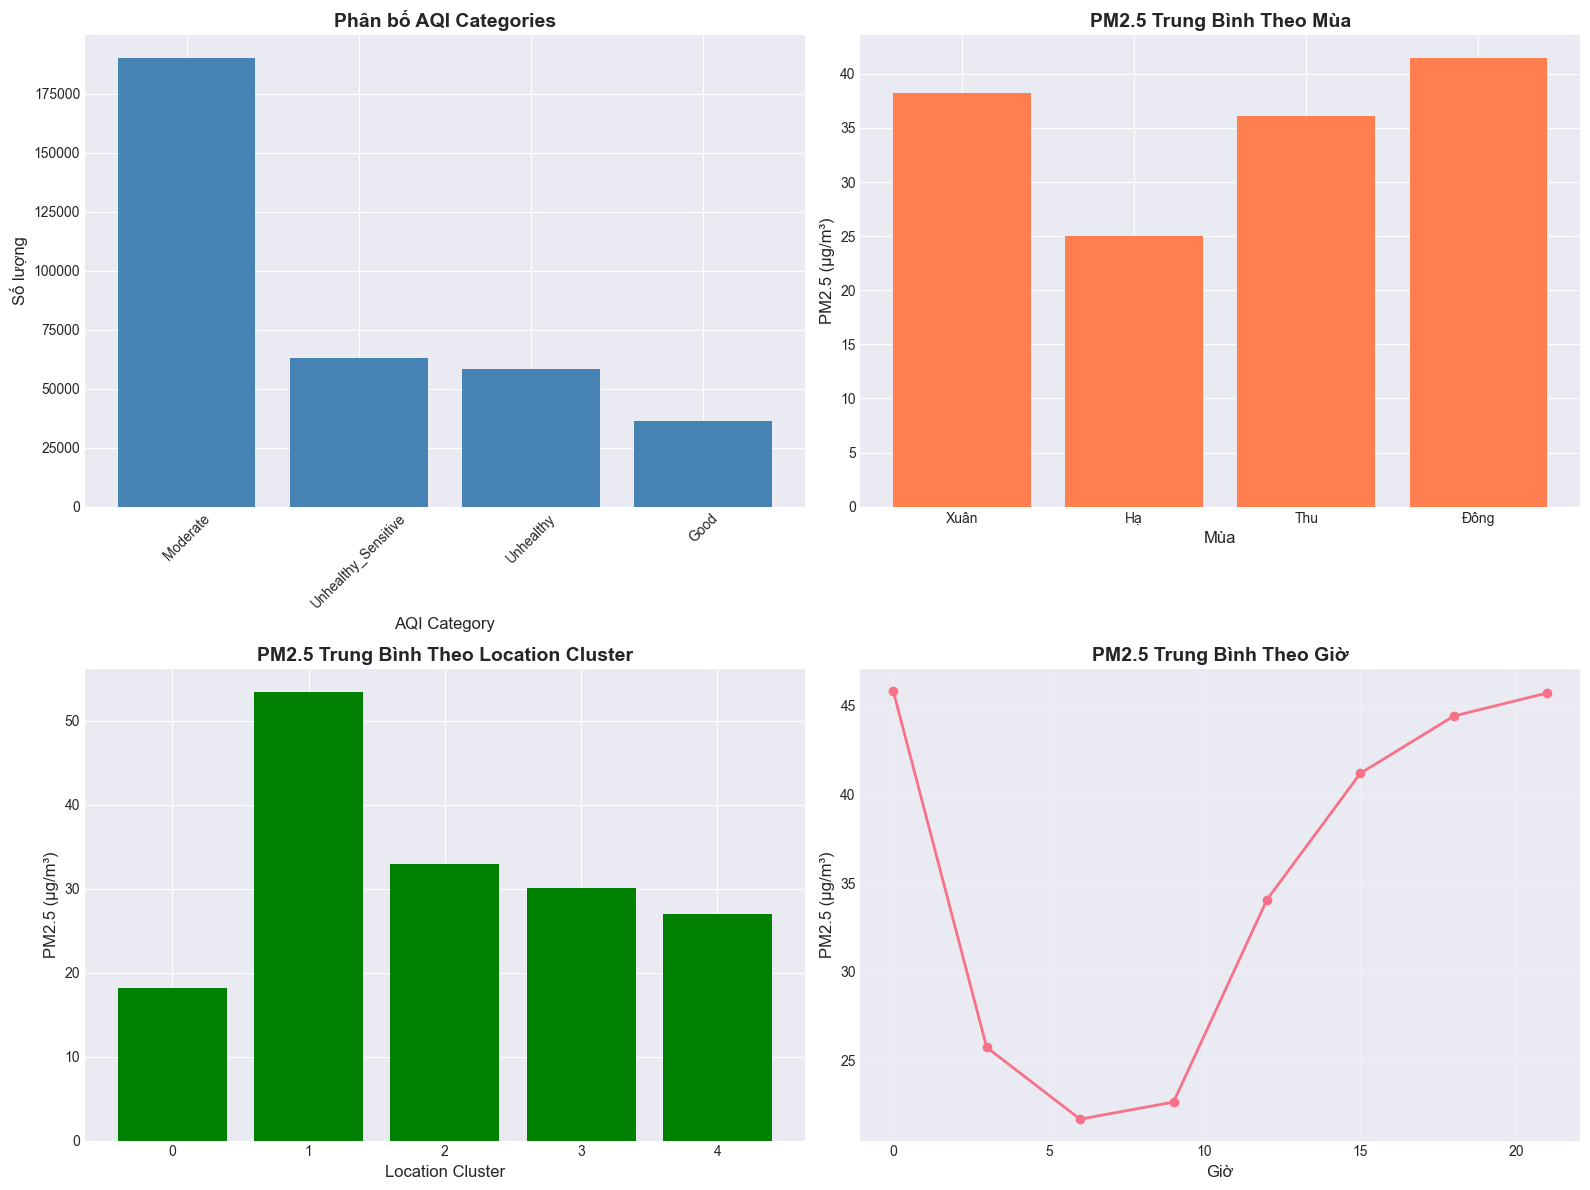

Đã hoàn thành phần Data Mining!


In [21]:
# 2.6. Visualization của patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Phân bố AQI categories
aqi_counts = df_preprocessed['aqi_category'].value_counts()
axes[0, 0].bar(aqi_counts.index, aqi_counts.values, color='steelblue')
axes[0, 0].set_title('Phân bố AQI Categories', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('AQI Category', fontsize=12)
axes[0, 0].set_ylabel('Số lượng', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. AQI theo season
season_aqi = df_preprocessed.groupby('season')['pm2p5'].mean()
axes[0, 1].bar(['Xuân', 'Hạ', 'Thu', 'Đông'], season_aqi.values, color='coral')
axes[0, 1].set_title('PM2.5 Trung Bình Theo Mùa', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Mùa', fontsize=12)
axes[0, 1].set_ylabel('PM2.5 (μg/m³)', fontsize=12)

# 3. AQI theo location cluster
cluster_aqi = df_preprocessed.groupby('location_cluster')['pm2p5'].mean()
axes[1, 0].bar(range(len(cluster_aqi)), cluster_aqi.values, color='green')
axes[1, 0].set_title('PM2.5 Trung Bình Theo Location Cluster', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Location Cluster', fontsize=12)
axes[1, 0].set_ylabel('PM2.5 (μg/m³)', fontsize=12)

# 4. AQI theo giờ trong ngày
hourly_aqi = df_preprocessed.groupby('hour')['pm2p5'].mean()
axes[1, 1].plot(hourly_aqi.index, hourly_aqi.values, marker='o', linewidth=2, markersize=6)
axes[1, 1].set_title('PM2.5 Trung Bình Theo Giờ', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Giờ', fontsize=12)
axes[1, 1].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Đã hoàn thành phần Data Mining!")


---
# PHẦN 3: MACHINE LEARNING


In [22]:
# 3.1. Chuẩn bị dữ liệu cho Machine Learning

print("=" * 80)
print("LOẠI BỎ FEATURES TƯƠNG QUAN CAO")
print("=" * 80)

# Features bị loại bỏ do tương quan cao
features_to_remove = [
    'temperature_2m',        # Tương quan cao với dewpoint_2m
    'apparent_temperature',   # Tương quan cao với temperature
    'vapour_pressure_deficit', # Thông tin đã có trong humidity
    'precipitation',          # Giữ rain và showers riêng biệt
    'windgusts_10m'          # Tương quan cao với windspeed_10m
]

print(f"\nCác features bị loại bỏ do tương quan cao:")
for feature in features_to_remove:
    print(f"  ❌ {feature}")

# Chọn features (GIỮ LẠI pollutant lag features)
feature_cols = [
    # Weather features (đã loại bỏ tương quan cao)
    'dewpoint_2m',  # Giữ lại thay vì temperature_2m và apparent_temperature
    'relativehumidity_2m',
    # 'vapour_pressure_deficit',  # ❌ Loại bỏ
    # 'precipitation',  # ❌ Loại bỏ
    'rain', 'showers', 'snowfall', 'snow_depth',
    'cloudcover', 'cloudcover_low', 'cloudcover_mid', 'cloudcover_high',
    'windspeed_10m', 'winddirection_10m',
    # 'windgusts_10m',  # ❌ Loại bỏ
    'pressure_msl', 'surface_pressure',
    
    # Temporal features
    'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'season',
    
    # Location features
    'province_encoded', 'location_cluster',
    
    # Engineered features (giữ lại nhưng cần cập nhật do loại bỏ temperature_2m)
    'wind_pressure',  # windspeed_10m * pressure_msl
    
    # Pollutant lag features (GIỮ LẠI theo yêu cầu)
    'pm2p5_lag1', 'pm10_lag1', 'pm2p5_rolling_mean_24h'
]

print(f"\n✅ Features được giữ lại: {len(feature_cols)} features")
print(f"\nDanh sách features:")
for i, feature in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {feature}")

# Loại bỏ các cột không tồn tại
available_features = [col for col in feature_cols if col in df_preprocessed.columns]

print(f"\n📊 Features có sẵn trong dataset: {len(available_features)}")

# Sort theo thời gian TRƯỚC KHI chia train/test
print("\n" + "=" * 80)
print("SORT DỮ LIỆU THEO THỜI GIAN (Chronological Order)")
print("=" * 80)

df_preprocessed = df_preprocessed.sort_values('time').reset_index(drop=True)
print(f"✅ Đã sort {len(df_preprocessed):,} dòng theo thời gian")
print(f"   Thời gian đầu: {df_preprocessed['time'].min()}")
print(f"   Thời gian cuối: {df_preprocessed['time'].max()}")

# Xóa các dòng có giá trị thiếu trong features
df_ml = df_preprocessed[available_features + ['pm2p5', 'pm10', 'province', 'time']].dropna()

X = df_ml[available_features]
y_pm25 = df_ml['pm2p5']
y_pm10 = df_ml['pm10']

print(f"\n{'=' * 80}")
print("TÓM TẮT DỮ LIỆU")
print(f"{'=' * 80}")
print(f"Số features: {len(available_features)}")
print(f"Số samples: {len(X):,}")
print(f"Khoảng thời gian: {df_ml['time'].min()} → {df_ml['time'].max()}")
print(f"\n{'=' * 80}")

LOẠI BỎ FEATURES TƯƠNG QUAN CAO

Các features bị loại bỏ do tương quan cao:
  ❌ temperature_2m
  ❌ apparent_temperature
  ❌ vapour_pressure_deficit
  ❌ precipitation
  ❌ windgusts_10m

✅ Features được giữ lại: 27 features

Danh sách features:
   1. dewpoint_2m
   2. relativehumidity_2m
   3. rain
   4. showers
   5. snowfall
   6. snow_depth
   7. cloudcover
   8. cloudcover_low
   9. cloudcover_mid
  10. cloudcover_high
  11. windspeed_10m
  12. winddirection_10m
  13. pressure_msl
  14. surface_pressure
  15. year
  16. month
  17. day
  18. hour
  19. day_of_week
  20. is_weekend
  21. season
  22. province_encoded
  23. location_cluster
  24. wind_pressure
  25. pm2p5_lag1
  26. pm10_lag1
  27. pm2p5_rolling_mean_24h

📊 Features có sẵn trong dataset: 27

SORT DỮ LIỆU THEO THỜI GIAN (Chronological Order)
✅ Đã sort 347,752 dòng theo thời gian
   Thời gian đầu: 2018-01-01 00:00:00
   Thời gian cuối: 2024-12-31 21:00:00

TÓM TẮT DỮ LIỆU
Số features: 27
Số samples: 347,752
Khoảng thời g

In [23]:
print(available_features)

['dewpoint_2m', 'relativehumidity_2m', 'rain', 'showers', 'snowfall', 'snow_depth', 'cloudcover', 'cloudcover_low', 'cloudcover_mid', 'cloudcover_high', 'windspeed_10m', 'winddirection_10m', 'pressure_msl', 'surface_pressure', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'season', 'province_encoded', 'location_cluster', 'wind_pressure', 'pm2p5_lag1', 'pm10_lag1', 'pm2p5_rolling_mean_24h']


In [24]:
# 3.2. Chia train/test split
# Chia theo thời gian (80% train, 20% test)
split_idx = int(len(X) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train_pm25 = y_pm25.iloc[:split_idx]
y_test_pm25 = y_pm25.iloc[split_idx:]
y_train_pm10 = y_pm10.iloc[:split_idx]
y_test_pm10 = y_pm10.iloc[split_idx:]

print(f"Train set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")


Train set: 278,201 samples
Test set: 69,551 samples


In [25]:
# 3.3. Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Đã chuẩn hóa dữ liệu")


Đã chuẩn hóa dữ liệu


In [26]:
# 3.4. Xây dựng các mô hình dự đoán PM2.5
models_pm25 = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=7,
        random_state=42,
        n_jobs=-1
    )
}

results_pm25 = {}

print("=== HUẤN LUYỆN MÔ HÌNH DỰ ĐOÁN PM2.5 ===")
for name, model in models_pm25.items():
    print(f"\nĐang huấn luyện {name}...")
    start_time = time.time()
    
    model.fit(X_train_scaled, y_train_pm25)
    
    # Dự đoán
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Tính metrics
    train_rmse = np.sqrt(mean_squared_error(y_train_pm25, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test_pm25, y_pred_test))
    train_mae = mean_absolute_error(y_train_pm25, y_pred_train)
    test_mae = mean_absolute_error(y_test_pm25, y_pred_test)
    train_r2 = r2_score(y_train_pm25, y_pred_train)
    test_r2 = r2_score(y_test_pm25, y_pred_test)
    
    training_time = time.time() - start_time
    
    results_pm25[name] = {
        'model': model,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'training_time': training_time
    }
    
    print(f"  Train RMSE: {train_rmse:.2f}, Test RMSE: {test_rmse:.2f}")
    print(f"  Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
    print(f"  Thời gian: {training_time:.2f}s")


=== HUẤN LUYỆN MÔ HÌNH DỰ ĐOÁN PM2.5 ===

Đang huấn luyện Linear Regression...
  Train RMSE: 11.72, Test RMSE: 11.93
  Train R²: 0.8057, Test R²: 0.8020
  Thời gian: 0.11s

Đang huấn luyện Ridge Regression...
  Train RMSE: 11.72, Test RMSE: 11.93
  Train R²: 0.8057, Test R²: 0.8020
  Thời gian: 0.04s

Đang huấn luyện Lasso Regression...
  Train RMSE: 11.95, Test RMSE: 12.22
  Train R²: 0.7980, Test R²: 0.7924
  Thời gian: 0.07s

Đang huấn luyện Random Forest...
  Train RMSE: 2.63, Test RMSE: 7.12
  Train R²: 0.9902, Test R²: 0.9294
  Thời gian: 56.47s

Đang huấn luyện Gradient Boosting...
  Train RMSE: 8.12, Test RMSE: 8.18
  Train R²: 0.9066, Test R²: 0.9069
  Thời gian: 73.81s

Đang huấn luyện XGBoost...
  Train RMSE: 6.26, Test RMSE: 7.01
  Train R²: 0.9447, Test R²: 0.9317
  Thời gian: 1.46s


In [27]:
# 3.5. Xây dựng các mô hình dự đoán PM10
models_pm10 = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=7,
        random_state=42,
        n_jobs=-1
    )
}

results_pm10 = {}

print("=== HUẤN LUYỆN MÔ HÌNH DỰ ĐOÁN PM10 ===")
for name, model in models_pm10.items():
    print(f"\nĐang huấn luyện {name}...")
    start_time = time.time()
    
    model.fit(X_train_scaled, y_train_pm10)
    
    # Dự đoán
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Tính metrics
    train_rmse = np.sqrt(mean_squared_error(y_train_pm10, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test_pm10, y_pred_test))
    train_mae = mean_absolute_error(y_train_pm10, y_pred_train)
    test_mae = mean_absolute_error(y_test_pm10, y_pred_test)
    train_r2 = r2_score(y_train_pm10, y_pred_train)
    test_r2 = r2_score(y_test_pm10, y_pred_test)
    
    training_time = time.time() - start_time
    
    results_pm10[name] = {
        'model': model,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'training_time': training_time
    }
    
    print(f"  Train RMSE: {train_rmse:.2f}, Test RMSE: {test_rmse:.2f}")
    print(f"  Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
    print(f"  Thời gian: {training_time:.2f}s")


=== HUẤN LUYỆN MÔ HÌNH DỰ ĐOÁN PM10 ===

Đang huấn luyện Linear Regression...
  Train RMSE: 16.42, Test RMSE: 16.72
  Train R²: 0.8039, Test R²: 0.8003
  Thời gian: 0.09s

Đang huấn luyện Ridge Regression...
  Train RMSE: 16.42, Test RMSE: 16.72
  Train R²: 0.8039, Test R²: 0.8003
  Thời gian: 0.04s

Đang huấn luyện Lasso Regression...
  Train RMSE: 16.63, Test RMSE: 16.99
  Train R²: 0.7989, Test R²: 0.7939
  Thời gian: 0.07s

Đang huấn luyện Random Forest...
  Train RMSE: 3.69, Test RMSE: 10.00
  Train R²: 0.9901, Test R²: 0.9285
  Thời gian: 59.86s

Đang huấn luyện Gradient Boosting...
  Train RMSE: 11.37, Test RMSE: 11.44
  Train R²: 0.9059, Test R²: 0.9065
  Thời gian: 74.81s

Đang huấn luyện XGBoost...
  Train RMSE: 8.78, Test RMSE: 9.82
  Train R²: 0.9439, Test R²: 0.9311
  Thời gian: 1.42s


In [28]:
# 3.6. Feature Importance (cho Random Forest)
rf_pm25 = results_pm25['Random Forest']['model']
feature_importance_pm25 = pd.DataFrame({
    'feature': available_features,
    'importance': rf_pm25.feature_importances_
}).sort_values('importance', ascending=False)

print("=== TOP 15 FEATURES QUAN TRỌNG NHẤT CHO PM2.5 ===")
print(feature_importance_pm25.head(15))


=== TOP 15 FEATURES QUAN TRỌNG NHẤT CHO PM2.5 ===
                   feature  importance
24              pm2p5_lag1    0.731597
17                    hour    0.123703
26  pm2p5_rolling_mean_24h    0.060192
25               pm10_lag1    0.010183
11       winddirection_10m    0.007520
13        surface_pressure    0.006697
12            pressure_msl    0.005846
0              dewpoint_2m    0.005725
1      relativehumidity_2m    0.005164
23           wind_pressure    0.005111
8           cloudcover_mid    0.004320
16                     day    0.004303
7           cloudcover_low    0.003831
15                   month    0.003755
10           windspeed_10m    0.003259


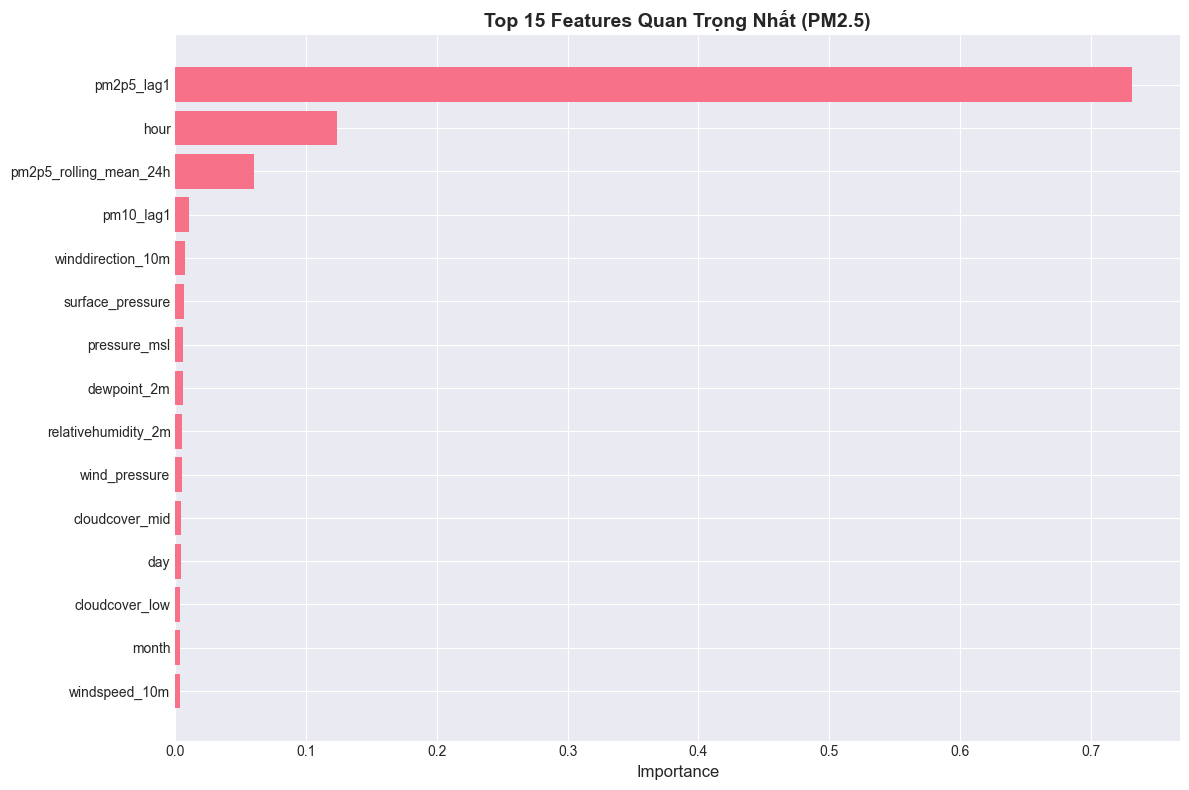

In [29]:
# Visualization feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance_pm25.head(15)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Features Quan Trọng Nhất (PM2.5)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


---
# PHẦN 4: EXPERIMENTAL EVALUATION


In [30]:
# 4.1. So sánh kết quả các mô hình
print("=== SO SÁNH KẾT QUẢ CÁC MÔ HÌNH ===\n")

# Tạo bảng so sánh cho PM2.5
comparison_pm25 = pd.DataFrame({
    'Model': list(results_pm25.keys()),
    'Train RMSE': [r['train_rmse'] for r in results_pm25.values()],
    'Test RMSE': [r['test_rmse'] for r in results_pm25.values()],
    'Train MAE': [r['train_mae'] for r in results_pm25.values()],
    'Test MAE': [r['test_mae'] for r in results_pm25.values()],
    'Train R²': [r['train_r2'] for r in results_pm25.values()],
    'Test R²': [r['test_r2'] for r in results_pm25.values()],
    'Training Time (s)': [r['training_time'] for r in results_pm25.values()]
})

print("=== KẾT QUẢ DỰ ĐOÁN PM2.5 ===")
print(comparison_pm25.round(4))


=== SO SÁNH KẾT QUẢ CÁC MÔ HÌNH ===

=== KẾT QUẢ DỰ ĐOÁN PM2.5 ===
               Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  \
0  Linear Regression     11.7206    11.9287     7.6455    7.7151    0.8057   
1   Ridge Regression     11.7206    11.9291     7.6451    7.7151    0.8057   
2   Lasso Regression     11.9486    12.2154     7.8093    7.8930    0.7980   
3      Random Forest      2.6298     7.1245     1.6274    4.4040    0.9902   
4  Gradient Boosting      8.1247     8.1786     5.2495    5.2226    0.9066   
5            XGBoost      6.2551     7.0053     4.0191    4.3364    0.9447   

   Test R²  Training Time (s)  
0   0.8020             0.1065  
1   0.8020             0.0403  
2   0.7924             0.0716  
3   0.9294            56.4667  
4   0.9069            73.8126  
5   0.9317             1.4609  


In [31]:
# Tạo bảng so sánh cho PM10
comparison_pm10 = pd.DataFrame({
    'Model': list(results_pm10.keys()),
    'Train RMSE': [r['train_rmse'] for r in results_pm10.values()],
    'Test RMSE': [r['test_rmse'] for r in results_pm10.values()],
    'Train MAE': [r['train_mae'] for r in results_pm10.values()],
    'Test MAE': [r['test_mae'] for r in results_pm10.values()],
    'Train R²': [r['train_r2'] for r in results_pm10.values()],
    'Test R²': [r['test_r2'] for r in results_pm10.values()],
    'Training Time (s)': [r['training_time'] for r in results_pm10.values()]
})

print("\n=== KẾT QUẢ DỰ ĐOÁN PM10 ===")
print(comparison_pm10.round(4))



=== KẾT QUẢ DỰ ĐOÁN PM10 ===
               Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  \
0  Linear Regression     16.4163    16.7194    10.7149   10.8197    0.8039   
1   Ridge Regression     16.4163    16.7197    10.7147   10.8197    0.8039   
2   Lasso Regression     16.6252    16.9892    10.8377   10.9283    0.7989   
3      Random Forest      3.6865    10.0026     2.2860    6.1869    0.9901   
4  Gradient Boosting     11.3709    11.4393     7.3244    7.2881    0.9059   
5            XGBoost      8.7792     9.8247     5.6406    6.0770    0.9439   

   Test R²  Training Time (s)  
0   0.8003             0.0907  
1   0.8003             0.0375  
2   0.7939             0.0685  
3   0.9285            59.8640  
4   0.9065            74.8140  
5   0.9311             1.4184  


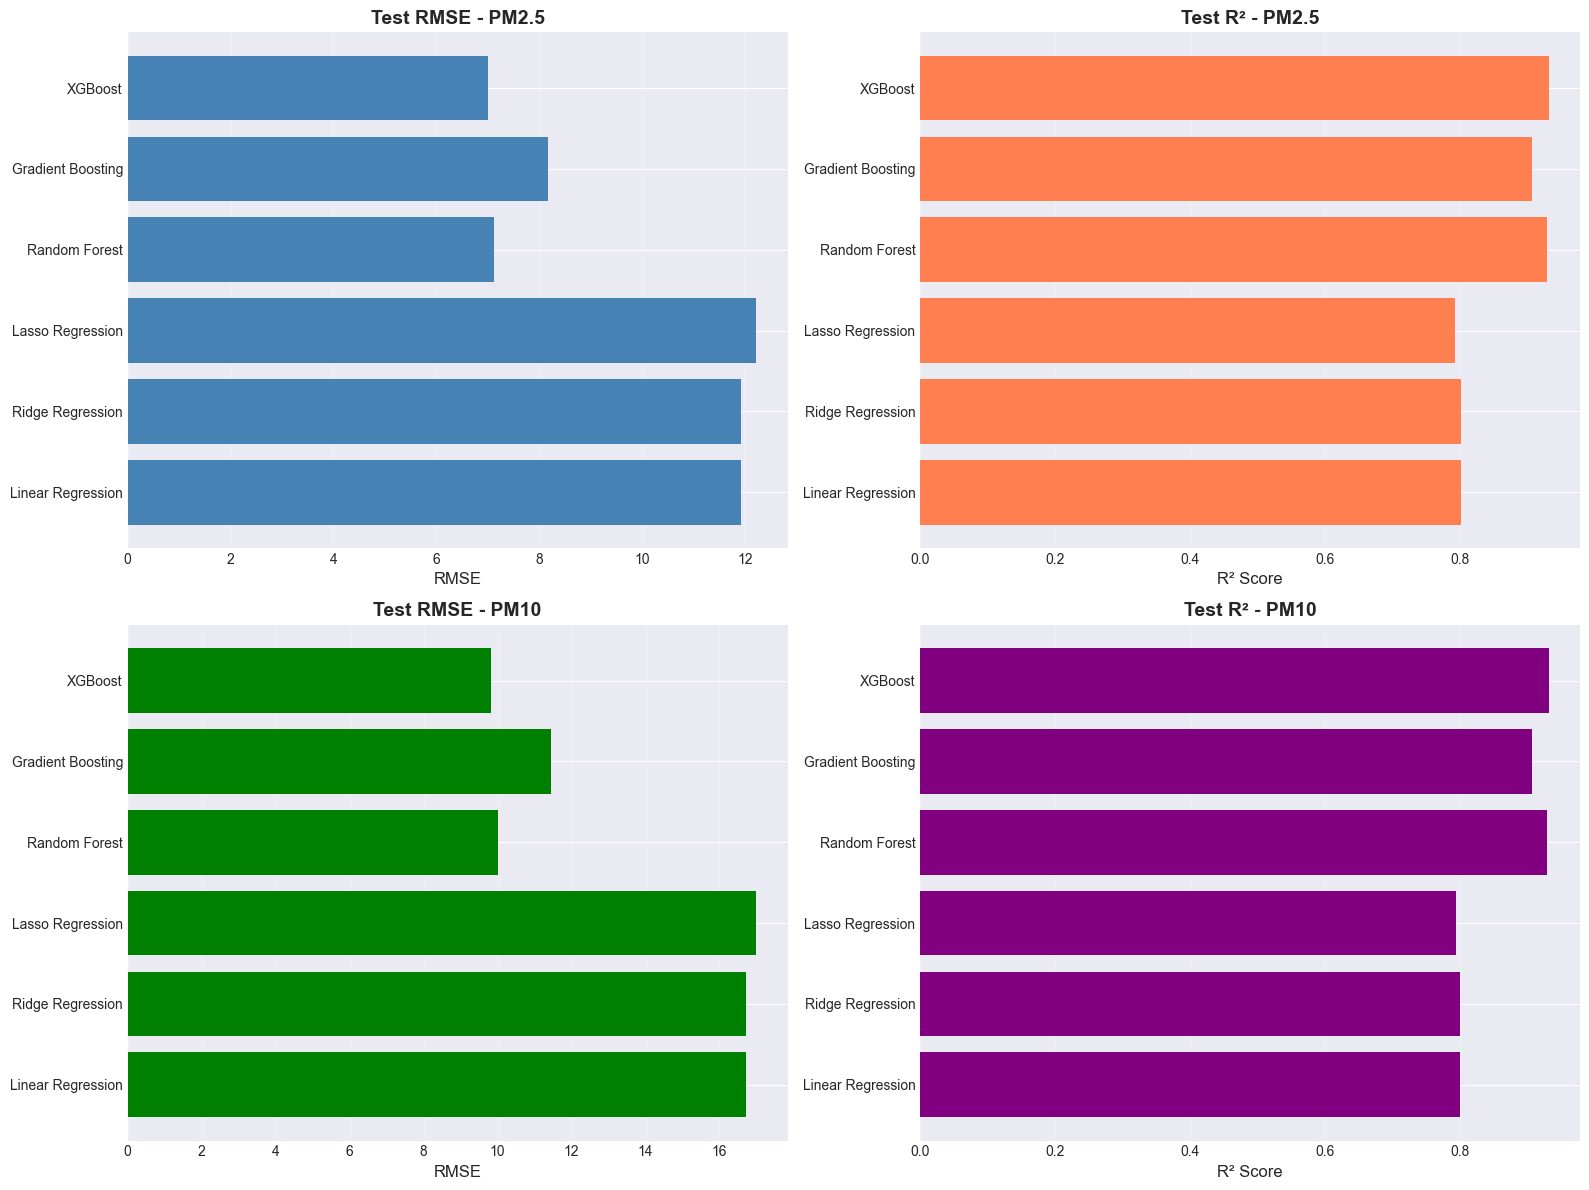

In [32]:
# 4.2. Visualization so sánh mô hình
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PM2.5 - Test RMSE
axes[0, 0].barh(comparison_pm25['Model'], comparison_pm25['Test RMSE'], color='steelblue')
axes[0, 0].set_title('Test RMSE - PM2.5', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('RMSE', fontsize=12)
axes[0, 0].grid(True, alpha=0.3, axis='x')

# PM2.5 - Test R²
axes[0, 1].barh(comparison_pm25['Model'], comparison_pm25['Test R²'], color='coral')
axes[0, 1].set_title('Test R² - PM2.5', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('R² Score', fontsize=12)
axes[0, 1].grid(True, alpha=0.3, axis='x')

# PM10 - Test RMSE
axes[1, 0].barh(comparison_pm10['Model'], comparison_pm10['Test RMSE'], color='green')
axes[1, 0].set_title('Test RMSE - PM10', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('RMSE', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# PM10 - Test R²
axes[1, 1].barh(comparison_pm10['Model'], comparison_pm10['Test R²'], color='purple')
axes[1, 1].set_title('Test R² - PM10', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('R² Score', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


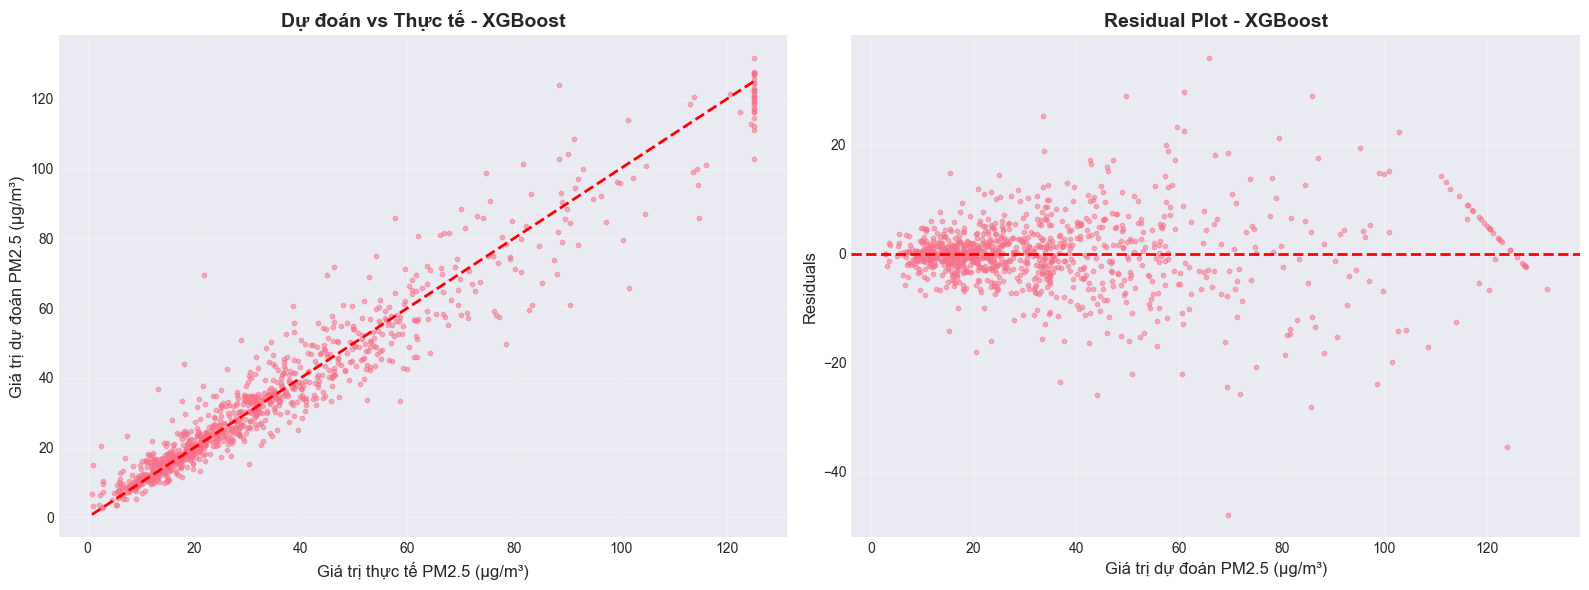

In [33]:
# 4.3. Visualization dự đoán vs thực tế (cho mô hình tốt nhất)
# Chọn mô hình tốt nhất (dựa trên Test R²)
best_model_pm25_name = comparison_pm25.loc[comparison_pm25['Test R²'].idxmax(), 'Model']
best_model_pm25 = results_pm25[best_model_pm25_name]['model']

y_pred_best_pm25 = best_model_pm25.predict(X_test_scaled)

# Lấy mẫu để visualization (1000 điểm)
sample_idx = np.random.choice(len(y_test_pm25), size=min(1000, len(y_test_pm25)), replace=False)
y_test_sample = y_test_pm25.iloc[sample_idx].values
y_pred_sample = y_pred_best_pm25[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(y_test_sample, y_pred_sample, alpha=0.5, s=10)
axes[0].plot([y_test_sample.min(), y_test_sample.max()], 
             [y_test_sample.min(), y_test_sample.max()], 'r--', lw=2)
axes[0].set_xlabel('Giá trị thực tế PM2.5 (μg/m³)', fontsize=12)
axes[0].set_ylabel('Giá trị dự đoán PM2.5 (μg/m³)', fontsize=12)
axes[0].set_title(f'Dự đoán vs Thực tế - {best_model_pm25_name}', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_test_sample - y_pred_sample
axes[1].scatter(y_pred_sample, residuals, alpha=0.5, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Giá trị dự đoán PM2.5 (μg/m³)', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title(f'Residual Plot - {best_model_pm25_name}', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [34]:
# 4.4. Đánh giá theo từng tỉnh/thành phố
# Lấy thông tin tỉnh cho test set
test_provinces = df_ml.iloc[split_idx:]['province'].values

# Tính metrics theo tỉnh
province_results = []
for province in np.unique(test_provinces):
    province_mask = test_provinces == province
    y_true_province = y_test_pm25[province_mask].values
    y_pred_province = y_pred_best_pm25[province_mask]
    
    rmse = np.sqrt(mean_squared_error(y_true_province, y_pred_province))
    mae = mean_absolute_error(y_true_province, y_pred_province)
    r2 = r2_score(y_true_province, y_pred_province)
    
    province_results.append({
        'Province': province,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'Samples': np.sum(province_mask)
    })

province_df = pd.DataFrame(province_results).sort_values('R²', ascending=False)

print("=== KẾT QUẢ THEO TỪNG TỈNH/THÀNH PHỐ ===")
print(province_df.round(4))


=== KẾT QUẢ THEO TỪNG TỈNH/THÀNH PHỐ ===
             Province     RMSE     MAE      R²  Samples
3             Bac_Kan   8.8276  6.0491  0.9181     4091
15            Nghe_An   7.4454  4.7173  0.9149     4091
2           Bac_Giang  10.3902  7.0941  0.9137     4091
14            Lao_Cai   5.8491  3.6773  0.9049     4092
11             Ha_Noi  11.5623  7.7569  0.9035     4092
12          Hai_Phong   9.2194  6.2337  0.9015     4091
8             Can_Tho   8.8549  5.9134  0.8848     4091
0            An_Giang   6.8993  4.5712  0.8818     4091
4            Bac_Lieu   5.6519  3.7897  0.8724     4092
10            Gia_Lai   4.0321  2.4653  0.8710     4092
5             Ben_Tre   6.4468  4.3854  0.8673     4091
13        Ho_Chi_Minh   6.6635  4.4316  0.8643     4091
9             Da_Nang   3.9170  2.4397  0.8643     4091
7              Ca_Mau   4.0016  2.6709  0.8395     4091
1   Ba_Ria_-_Vung_Tau   5.1112  3.3465  0.8285     4091
16         Ninh_Thuan   3.4345  2.1308  0.7760     4091
6      

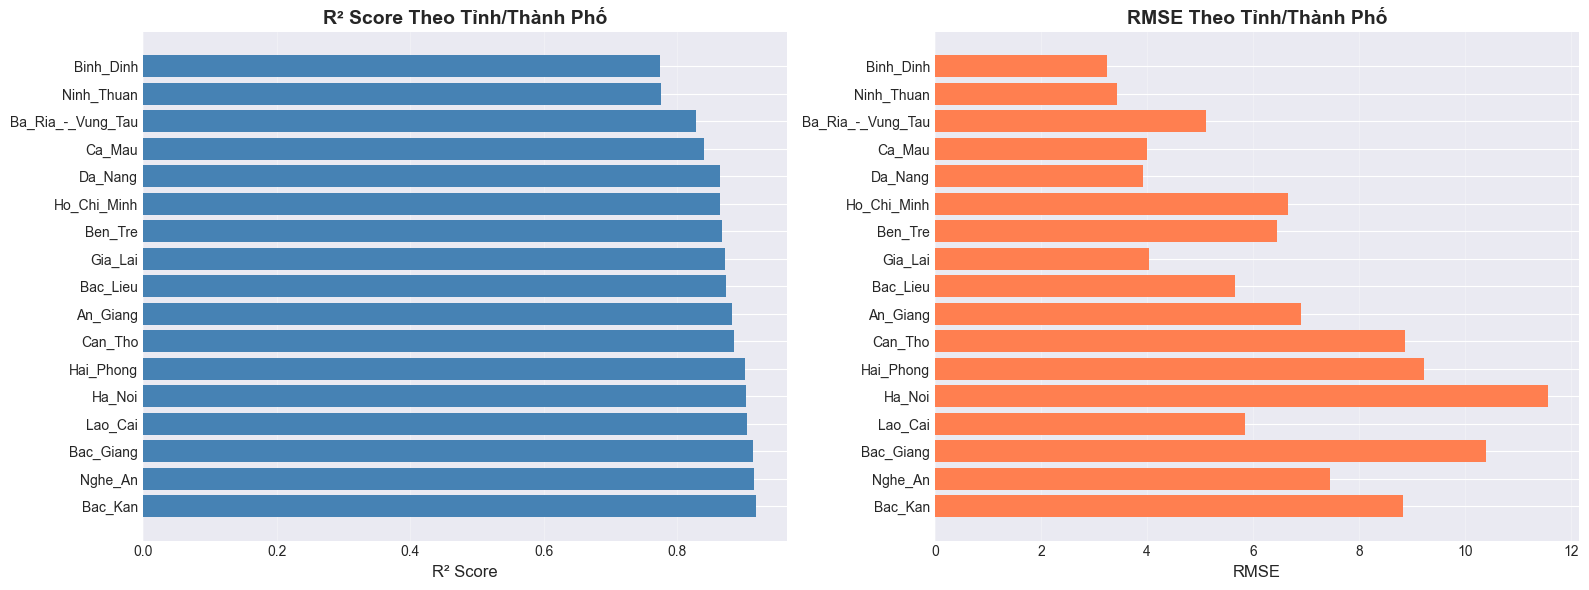

In [35]:
# Visualization kết quả theo tỉnh
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² theo tỉnh
axes[0].barh(province_df['Province'], province_df['R²'], color='steelblue')
axes[0].set_title('R² Score Theo Tỉnh/Thành Phố', fontsize=14, fontweight='bold')
axes[0].set_xlabel('R² Score', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')

# RMSE theo tỉnh
axes[1].barh(province_df['Province'], province_df['RMSE'], color='coral')
axes[1].set_title('RMSE Theo Tỉnh/Thành Phố', fontsize=14, fontweight='bold')
axes[1].set_xlabel('RMSE', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


In [36]:
# 4.5. Tóm tắt đánh giá
print("=" * 70)
print("TÓM TẮT ĐÁNH GIÁ THỰC NGHIỆM")
print("=" * 70)

print(f"\n1. MÔ HÌNH TỐT NHẤT CHO PM2.5:")
print(f"   - Mô hình: {best_model_pm25_name}")
best_pm25 = comparison_pm25.loc[comparison_pm25['Test R²'].idxmax()]
print(f"   - Test RMSE: {best_pm25['Test RMSE']:.4f} μg/m³")
print(f"   - Test MAE: {best_pm25['Test MAE']:.4f} μg/m³")
print(f"   - Test R²: {best_pm25['Test R²']:.4f}")

best_model_pm10_name = comparison_pm10.loc[comparison_pm10['Test R²'].idxmax(), 'Model']
best_pm10 = comparison_pm10.loc[comparison_pm10['Test R²'].idxmax()]

print(f"\n2. MÔ HÌNH TỐT NHẤT CHO PM10:")
print(f"   - Mô hình: {best_model_pm10_name}")
print(f"   - Test RMSE: {best_pm10['Test RMSE']:.4f} μg/m³")
print(f"   - Test MAE: {best_pm10['Test MAE']:.4f} μg/m³")
print(f"   - Test R²: {best_pm10['Test R²']:.4f}")

print(f"\n3. ĐÁNH GIÁ THEO TỈNH:")
print(f"   - Tỉnh có R² cao nhất: {province_df.loc[province_df['R²'].idxmax(), 'Province']} ({province_df['R²'].max():.4f})")
print(f"   - Tỉnh có R² thấp nhất: {province_df.loc[province_df['R²'].idxmin(), 'Province']} ({province_df['R²'].min():.4f})")
print(f"   - R² trung bình: {province_df['R²'].mean():.4f}")

print(f"\n4. FEATURES QUAN TRỌNG NHẤT:")
print(f"   Top 5 features:")
for idx, row in feature_importance_pm25.head(5).iterrows():
    print(f"   - {row['feature']}: {row['importance']:.4f}")

print("\n" + "=" * 70)


TÓM TẮT ĐÁNH GIÁ THỰC NGHIỆM

1. MÔ HÌNH TỐT NHẤT CHO PM2.5:
   - Mô hình: XGBoost
   - Test RMSE: 7.0053 μg/m³
   - Test MAE: 4.3364 μg/m³
   - Test R²: 0.9317

2. MÔ HÌNH TỐT NHẤT CHO PM10:
   - Mô hình: XGBoost
   - Test RMSE: 9.8247 μg/m³
   - Test MAE: 6.0770 μg/m³
   - Test R²: 0.9311

3. ĐÁNH GIÁ THEO TỈNH:
   - Tỉnh có R² cao nhất: Bac_Kan (0.9181)
   - Tỉnh có R² thấp nhất: Binh_Dinh (0.7748)
   - R² trung bình: 0.8695

4. FEATURES QUAN TRỌNG NHẤT:
   Top 5 features:
   - pm2p5_lag1: 0.7316
   - hour: 0.1237
   - pm2p5_rolling_mean_24h: 0.0602
   - pm10_lag1: 0.0102
   - winddirection_10m: 0.0075



# Save the model weights

In [37]:
import joblib
import pickle
from datetime import datetime

# Tạo thư mục lưu models nếu chưa tồn tại
import os
model_dir = 'saved_models'
os.makedirs(model_dir, exist_ok=True)

# Lấy mô hình XGBoost đã train
xgb_pm25 = results_pm25['XGBoost']['model']
xgb_pm10 = results_pm10['XGBoost']['model']

# Lưu mô hình XGBoost cho PM2.5
model_pm25_path = os.path.join(model_dir, 'xgboost_pm25_model.pkl')
joblib.dump(xgb_pm25, model_pm25_path)
print(f"✅ Đã lưu mô hình XGBoost PM2.5 tại: {model_pm25_path}")

# Lưu mô hình XGBoost cho PM10
model_pm10_path = os.path.join(model_dir, 'xgboost_pm10_model.pkl')
joblib.dump(xgb_pm10, model_pm10_path)
print(f"✅ Đã lưu mô hình XGBoost PM10 tại: {model_pm10_path}")

# Lưu scaler
scaler_path = os.path.join(model_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✅ Đã lưu scaler tại: {scaler_path}")

# Lưu danh sách features
features_path = os.path.join(model_dir, 'feature_names.pkl')
joblib.dump(available_features, features_path)
print(f"✅ Đã lưu danh sách features tại: {features_path}")

# Lưu label encoder cho province
le_path = os.path.join(model_dir, 'label_encoder_province.pkl')
joblib.dump(le_province, le_path)
print(f"✅ Đã lưu label encoder tại: {le_path}")

# Lưu metadata
metadata = {
    'train_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'model_pm25_metrics': {
        'test_rmse': results_pm25['XGBoost']['test_rmse'],
        'test_mae': results_pm25['XGBoost']['test_mae'],
        'test_r2': results_pm25['XGBoost']['test_r2']
    },
    'model_pm10_metrics': {
        'test_rmse': results_pm10['XGBoost']['test_rmse'],
        'test_mae': results_pm10['XGBoost']['test_mae'],
        'test_r2': results_pm10['XGBoost']['test_r2']
    },
    'n_features': len(available_features),
    'n_train_samples': len(X_train),
    'n_test_samples': len(X_test)
}

metadata_path = os.path.join(model_dir, 'model_metadata.pkl')
joblib.dump(metadata, metadata_path)
print(f"✅ Đã lưu metadata tại: {metadata_path}")

print("\n" + "=" * 70)
print("ĐÃ LƯU TẤT CẢ CÁC FILES CẦN THIẾT ĐỂ DỰ ĐOÁN")
print("=" * 70)
print(f"\nCác files đã lưu:")
print(f"1. {model_pm25_path}")
print(f"2. {model_pm10_path}")
print(f"3. {scaler_path}")
print(f"4. {features_path}")
print(f"5. {le_path}")
print(f"6. {metadata_path}")
print("\n" + "=" * 70)

# Demo: Load lại và test prediction
print("\nDEMO: Load lại model và thực hiện dự đoán...")
loaded_model_pm25 = joblib.load(model_pm25_path)
loaded_scaler = joblib.load(scaler_path)
loaded_features = joblib.load(features_path)

# Test với 1 sample từ test set
sample_data = X_test.iloc[0:1][loaded_features]
sample_scaled = loaded_scaler.transform(sample_data)
prediction = loaded_model_pm25.predict(sample_scaled)

print(f"Giá trị thực tế PM2.5: {y_test_pm25.iloc[0]:.2f} μg/m³")
print(f"Giá trị dự đoán PM2.5: {prediction[0]:.2f} μg/m³")
print("\n✅ Model đã sẵn sàng để sử dụng!")

✅ Đã lưu mô hình XGBoost PM2.5 tại: saved_models/xgboost_pm25_model.pkl
✅ Đã lưu mô hình XGBoost PM10 tại: saved_models/xgboost_pm10_model.pkl
✅ Đã lưu scaler tại: saved_models/scaler.pkl
✅ Đã lưu danh sách features tại: saved_models/feature_names.pkl
✅ Đã lưu label encoder tại: saved_models/label_encoder_province.pkl
✅ Đã lưu metadata tại: saved_models/model_metadata.pkl

ĐÃ LƯU TẤT CẢ CÁC FILES CẦN THIẾT ĐỂ DỰ ĐOÁN

Các files đã lưu:
1. saved_models/xgboost_pm25_model.pkl
2. saved_models/xgboost_pm10_model.pkl
3. saved_models/scaler.pkl
4. saved_models/feature_names.pkl
5. saved_models/label_encoder_province.pkl
6. saved_models/model_metadata.pkl


DEMO: Load lại model và thực hiện dự đoán...
Giá trị thực tế PM2.5: 31.28 μg/m³
Giá trị dự đoán PM2.5: 35.22 μg/m³

✅ Model đã sẵn sàng để sử dụng!
